### Descriptive and Diagnostic Analytics on Titanic Passenger Survival 

#### 1. Final Check After Cleaning

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load cleaned dataset
df_cleaned = pd.read_csv("titanic_cleaned.csv")

# Keep df as a short alias if you want to inspect the data manually
df = df_cleaned.copy()

# View first rows
df_cleaned.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Deck,FamilySize,IsAlone,AgeGroup,FareGroup
0,0,3,male,22.0,1,0,7.2500,S,0,Unknown,2,0,Young Adult,Low Fare
1,1,1,female,38.0,1,0,71.2833,C,1,C,2,0,Adult,Very High Fare
2,1,3,female,26.0,0,0,7.9250,S,0,Unknown,1,1,Young Adult,Medium Fare
3,1,1,female,35.0,1,0,53.1000,S,1,C,2,0,Young Adult,Very High Fare
4,0,3,male,35.0,0,0,8.0500,S,0,Unknown,1,1,Young Adult,Medium Fare


In [7]:
df_cleaned.shape

(891, 14)

In [8]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    str    
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    str    
 8   HasCabin    891 non-null    int64  
 9   Deck        891 non-null    str    
 10  FamilySize  891 non-null    int64  
 11  IsAlone     891 non-null    int64  
 12  AgeGroup    891 non-null    str    
 13  FareGroup   891 non-null    str    
dtypes: float64(2), int64(7), str(5)
memory usage: 97.6 KB


In [9]:
df_cleaned.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
HasCabin      0
Deck          0
FamilySize    0
IsAlone       0
AgeGroup      0
FareGroup     0
dtype: int64

In [10]:
df_cleaned.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208,0.228956,1.904602,0.602694
std,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429,0.420397,1.613459,0.489615
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400,0.000000,1.000000,0.000000
50%,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200,0.000000,1.000000,1.000000
75%,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000,0.000000,2.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,11.000000,1.000000


###### After cleaning the dataset, missing values were handled, unnecessary columns were removed, and new useful columns such as FamilySize, IsAlone, AgeGroup, FareGroup, HasCabin, and Deck were created. The cleaned dataset was then used for descriptive and diagnostic analytics.

#### 2. Descriptive Analytics

##### A. Count of Survivors and Non-Survivors

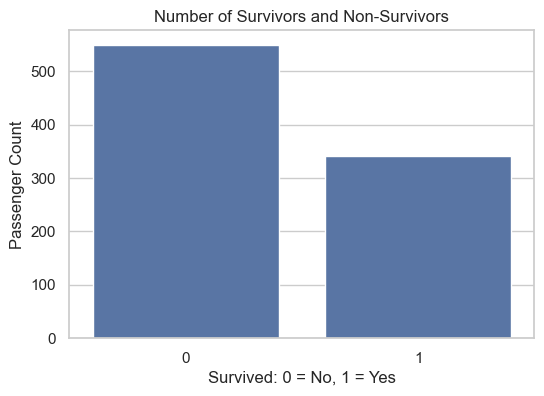

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_cleaned, x="Survived")
plt.title("Number of Survivors and Non-Survivors")
plt.xlabel("Survived: 0 = No, 1 = Yes")
plt.ylabel("Passenger Count")
plt.show()

###### This chart shows the total number of passengers who survived and did not survive. It helps describe the overall survival outcome in the dataset.

##### B. Survival Count by Sex

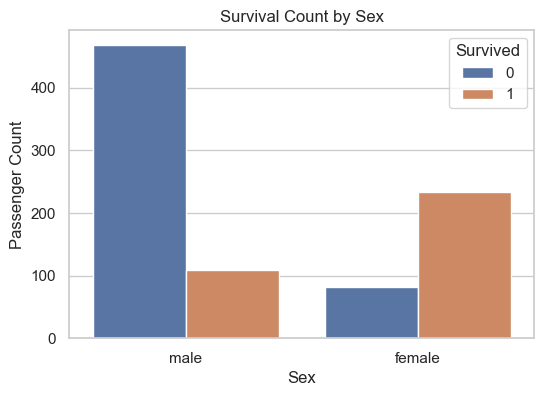

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_cleaned, x="Sex", hue="Survived")
plt.title("Survival Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Passenger Count")
plt.show()

###### This chart describes the number of male and female passengers who survived and did not survive.

##### C. Survival Count by Passenger Class

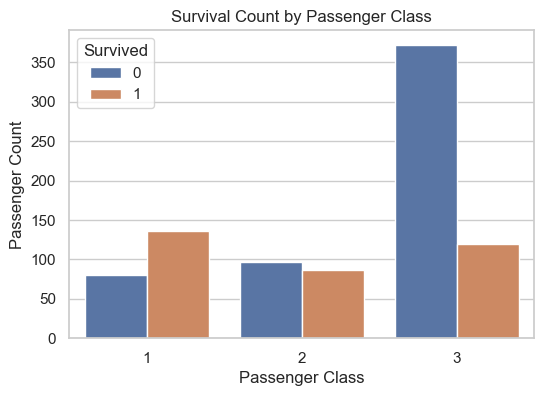

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_cleaned, x="Pclass", hue="Survived")
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Passenger Count")
plt.show()

###### This chart shows the survival distribution across first, second, and third-class passengers.

##### D. Age Distribution

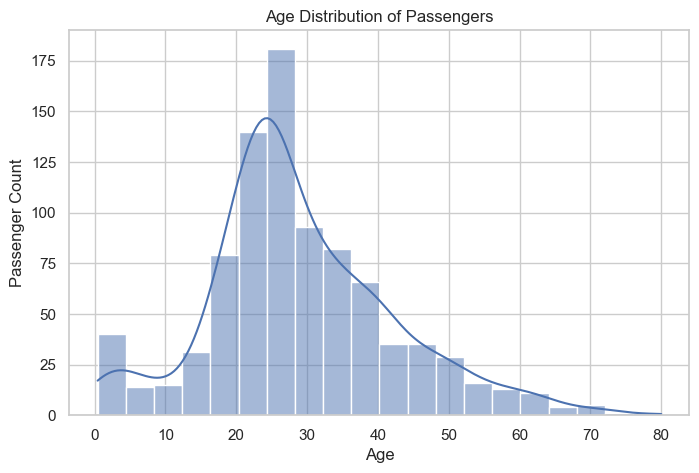

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned["Age"], bins=20, kde=True)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.show()

###### This chart shows the age distribution of passengers in the Titanic dataset.

##### E. Passenger Count by Age Group

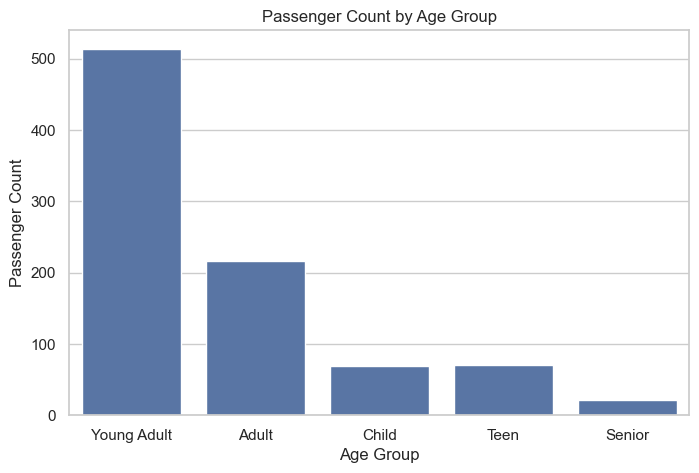

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x="AgeGroup")
plt.title("Passenger Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Passenger Count")
plt.show()

#### 3. Diagnostic Analytics

##### A. Survival Rate by Sex

In [16]:
sex_survival = df_cleaned.groupby("Sex")["Survived"].mean() * 100
sex_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

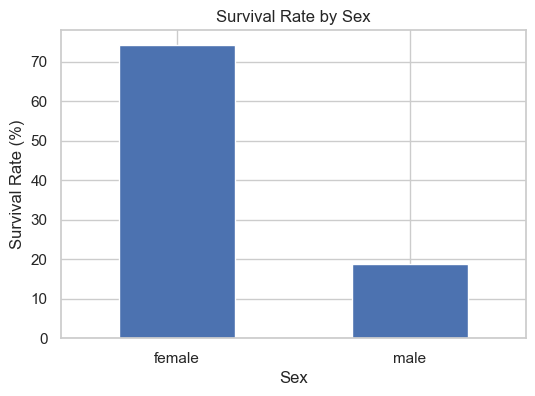

In [17]:
plt.figure(figsize=(6,4))
sex_survival.plot(kind="bar")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

###### This analysis shows whether survival rate differs between male and female passengers. A higher survival rate in one group suggests that sex may be related to survival outcome.

##### B. Survival Rate by Passenger Class

In [18]:
class_survival = df_cleaned.groupby("Pclass")["Survived"].mean() * 100
class_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

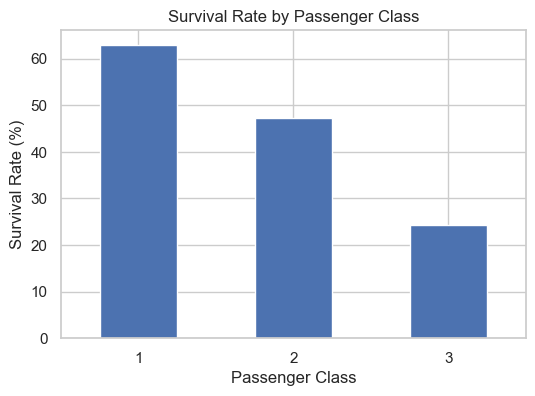

In [19]:
plt.figure(figsize=(6,4))
class_survival.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

###### This analysis helps identify whether passenger class is associated with survival. It compares the percentage of survivors in each class.

##### C. Survival Rate by Age Group

In [20]:
age_survival = df_cleaned.groupby("AgeGroup")["Survived"].mean() * 100
age_survival

AgeGroup
Adult          38.425926
Child          57.971014
Senior         22.727273
Teen           42.857143
Young Adult    35.797665
Name: Survived, dtype: float64

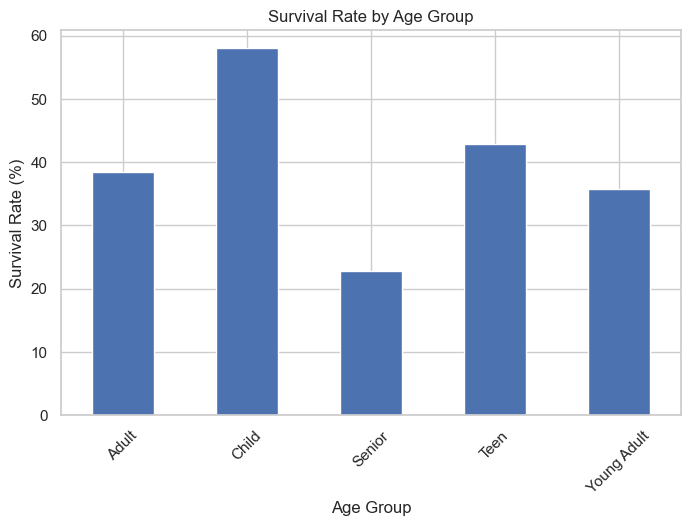

In [21]:
plt.figure(figsize=(8,5))
age_survival.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=45)
plt.show()

###### This analysis checks whether age group is related to survival rate.

##### D. Survival Rate by Family Size

In [22]:
family_survival = df_cleaned.groupby("FamilySize")["Survived"].mean() * 100
family_survival

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

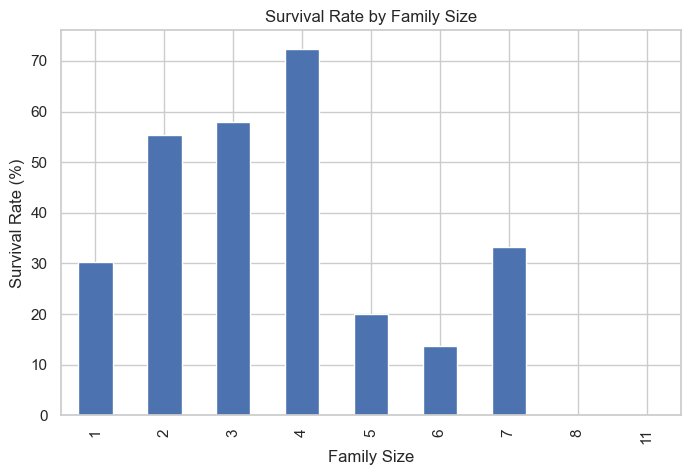

In [23]:
plt.figure(figsize=(8,5))
family_survival.plot(kind="bar")
plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.show()

###### This analysis shows whether passengers traveling alone or with family had different survival rates.

##### E. Survival Rate by Cabin Availability

In [24]:
cabin_survival = df_cleaned.groupby("HasCabin")["Survived"].mean() * 100
cabin_survival

HasCabin
0    29.985444
1    66.666667
Name: Survived, dtype: float64

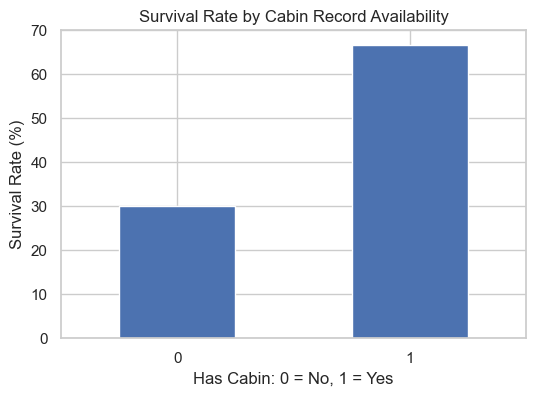

In [25]:
plt.figure(figsize=(6,4))
cabin_survival.plot(kind="bar")
plt.title("Survival Rate by Cabin Record Availability")
plt.xlabel("Has Cabin: 0 = No, 1 = Yes")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

###### This analysis checks whether passengers with recorded cabin information had different survival rates compared to those without cabin records. However, this does not mean the cabin itself caused survival; it may also be related to passenger class or ticket type.

#### 4. Correlation Analysis

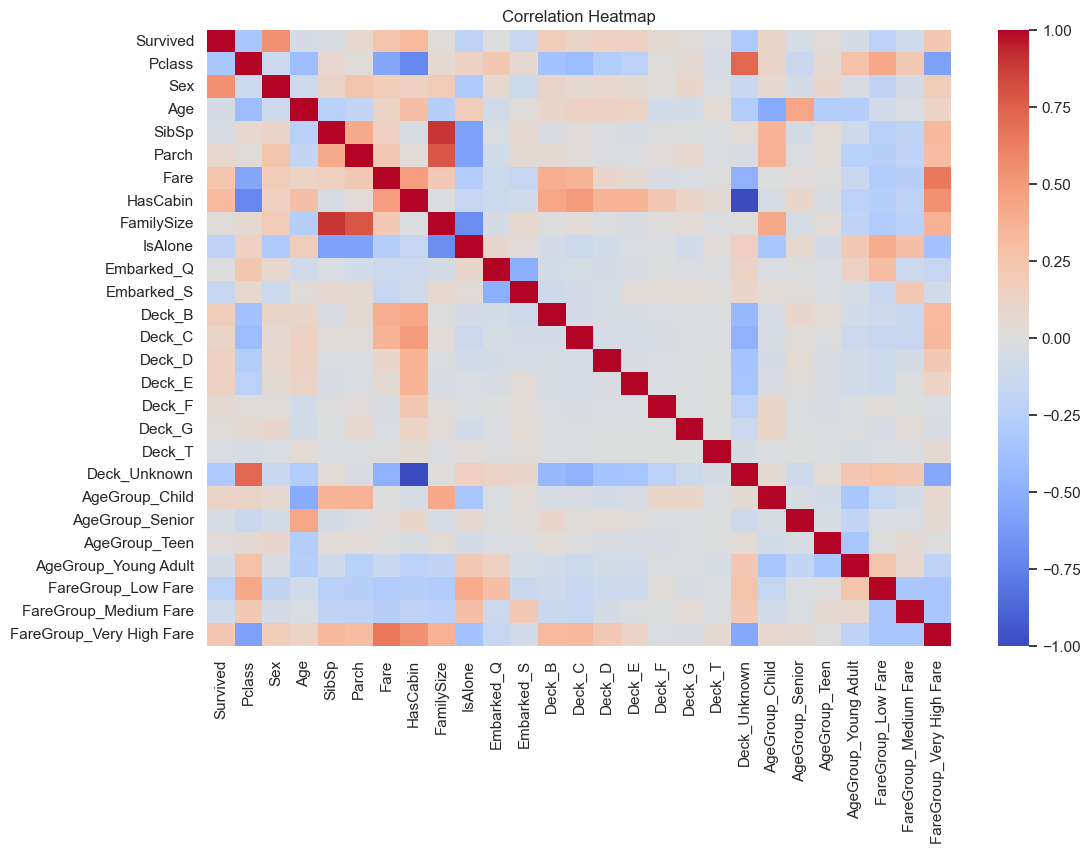

In [26]:
df_corr = df_cleaned.copy()

df_corr["Sex"] = df_corr["Sex"].map({"male": 0, "female": 1})

df_corr = pd.get_dummies(
    df_corr,
    columns=["Embarked", "Deck", "AgeGroup", "FareGroup"],
    drop_first=True
)

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


###### Then check correlation with survival:

In [27]:
corr["Survived"].sort_values(ascending=False)

Survived                    1.000000
Sex                         0.543351
HasCabin                    0.316912
Fare                        0.257307
FareGroup_Very High Fare    0.233638
Deck_B                      0.175095
Deck_D                      0.150716
Deck_E                      0.145321
AgeGroup_Child              0.116691
Deck_C                      0.114652
Parch                       0.081629
Deck_F                      0.057935
AgeGroup_Teen               0.026859
FamilySize                  0.016639
Deck_G                      0.016040
Embarked_Q                  0.003650
Deck_T                     -0.026456
SibSp                      -0.035322
AgeGroup_Senior            -0.051224
Age                        -0.059579
AgeGroup_Young Adult       -0.062094
FareGroup_Medium Fare      -0.095648
Embarked_S                 -0.149683
IsAlone                    -0.203367
FareGroup_Low Fare         -0.221610
Deck_Unknown               -0.316912
Pclass                     -0.338481
N

###### Correlation analysis was used to identify which numeric variables have stronger positive or negative relationships with survival. This supports the diagnostic analysis by showing which features are more associated with the survival outcome.

#### 5. Summary of Key Findings

In [29]:
summary = pd.DataFrame({
    "Metric": [
        "Overall survival rate",
        "Female survival rate",
        "Male survival rate",
        "1st class survival rate",
        "2nd class survival rate",
        "3rd class survival rate",
        "Passengers with cabin record",
        "Passengers without cabin record",
        "Passengers traveling alone",
        "Passengers traveling with family"
    ],
    "Survival Rate (%)": [
        df_cleaned["Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["Sex"] == "female", "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["Sex"] == "male", "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["Pclass"] == 1, "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["Pclass"] == 2, "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["Pclass"] == 3, "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["HasCabin"] == 1, "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["HasCabin"] == 0, "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["IsAlone"] == 1, "Survived"].mean() * 100,
        df_cleaned.loc[df_cleaned["IsAlone"] == 0, "Survived"].mean() * 100
    ]
})

summary["Survival Rate (%)"] = summary["Survival Rate (%)"].round(2)
summary


,Metric,Survival Rate (%)
0,Overall survival rate,38.38
1,Female survival rate,74.20
2,Male survival rate,18.89
3,1st class survival rate,62.96
4,2nd class survival rate,47.28
5,3rd class survival rate,24.24
6,Passengers with cabin record,66.67
7,Passengers without cabin record,29.99
8,Passengers traveling alone,30.35
9,Passengers traveling with family,50.56


#### 6. Conclusion

Based on the descriptive and diagnostic analytics, survival on the Titanic was strongly associated with passenger sex, class, fare level, cabin record availability, and family size. Female passengers had a much higher survival rate than male passengers, and first-class passengers survived at a higher rate than second- and third-class passengers. Children also had a higher survival rate than most older age groups. Passengers with recorded cabin information had a higher survival rate, but this should be interpreted carefully because cabin availability is also related to passenger class and fare. Overall, the results suggest that social priority, passenger class, and travel situation were important factors connected to survival.